In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyrpl.UMZI_lock import RPLockboxMZI
import time

obj = RPLockboxMZI(hostname="10.135.71.245", gui=True, config_file='default_config', yml_file='lockbox_config.yml')

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    default_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe default_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('default_config')
in a python terminal.


THIS IS TIMO!!!!


INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 10.135.71.245.


ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 1
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 2
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 3
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 4
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 5
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 6
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 7
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at ad

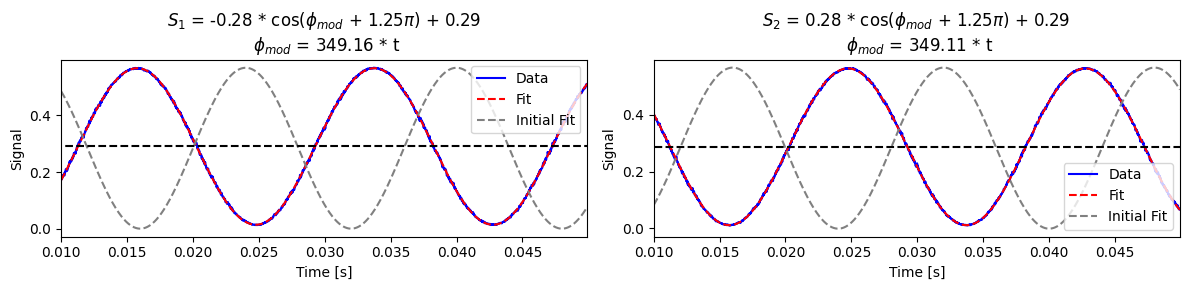

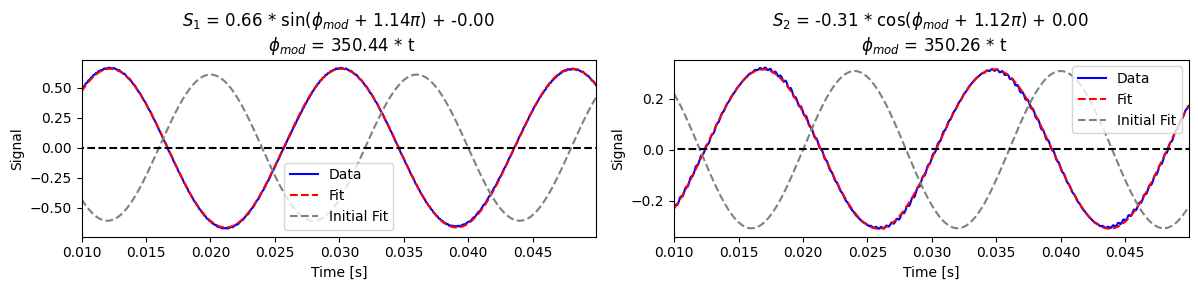

In [7]:
phi_setpoint = 1 * np.pi / 4

obj.calibrate(do_plot=True)
plt.show()
plt.show()
txt = input("Fit succeeded? (y/n): ")
if txt.lower() == 'y':
      obj.setup_locking(phi_setpoint)
      obj.rp.iq0.setup(output_direct="out1")
      obj.rp.asg0.setup(output_direct="off")
      obj.rp.pid0.setup(output_direct="out1")
      obj.rp.pid0.reg_integral = 0.0
      obj.setup_intermittent_locking(unlock_duration=50e-6)

In [3]:
obj.det_model_ch1.fit_result.params.pretty_print()

Name             Value      Min      Max   Stderr     Vary     Expr Brute_Step
det_1_V_pi      0.2853     -inf      inf     None     True     None     None
det_1_amp        -1.31     -inf     -0.1     None     True     None     None
det_1_freq          10        9       11     None    False     None     None
det_1_offset        -1       -1        1     None     True     None     None
det_1_phase      2.692   -6.283    6.283     None     True     None     None
det_1_t0             0    -0.25     0.25     None    False     None     None


In [3]:
obj.iq_model_ch1.fit_result.params.pretty_print()

Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
iq_1_V_pi      0.1412        0        1     None     True     None     None
iq_1_amp       0.2087      0.1      inf     None     True     None     None
iq_1_freq         9.5        9       11     None     True     None     None
iq_1_offset    0.0653     -0.3      0.3     None     True     None     None
iq_1_phase    -0.5945   -6.283    6.283     None     True     None     None
iq_1_t0             0    -0.25     0.25     None    False     None     None


In [8]:
obj.setup_locking(np.pi/4)

In [88]:
obj.rp.pid0.current_output_signal

-0.01330728848736418

ERROR:paramiko.transport:Socket exception: An existing connection was forcibly closed by the remote host (10054)


In [9]:
obj.det_model_ch1.phase_relation(np.pi/4)


0.09524973867030334

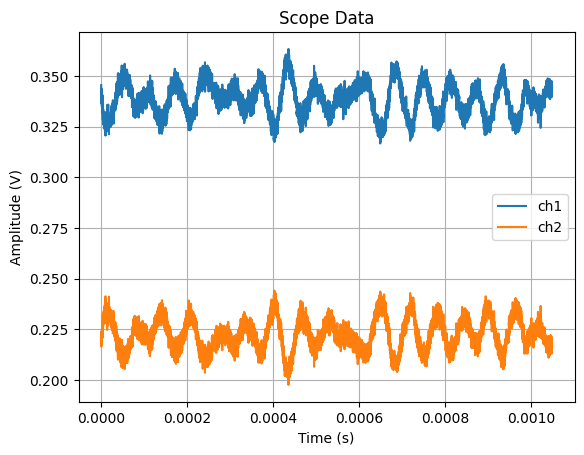

In [28]:
curve1, curve2 = obj.rp.scope.save_curve()
time, ch1 = curve1.data
time, ch2 = curve2.data

plt.figure()
plt.plot(time, ch1, label='ch1')
plt.plot(time, ch2, label='ch2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.title('Scope Data')
plt.legend()
plt.grid()
plt.show()

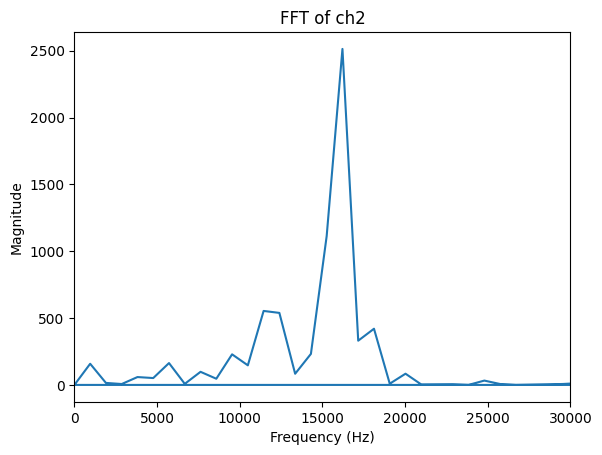

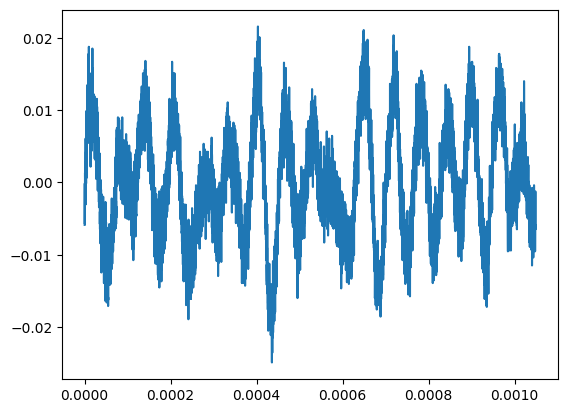

In [29]:
output_FT = np.fft.fft(ch2-np.mean(ch2))
frequencies = np.fft.fftfreq(len(ch2), d=(time[1] - time[0]))
plt.figure()
plt.plot(frequencies, np.abs(output_FT)**2, label='FFT of ch2')
# plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 30000)  # Limit x-axis to 1000 Hz
plt.title('FFT of ch2')
plt.show()

plt.figure()
plt.plot(time, ch2-np.mean(ch2))

In [3]:
obj.det_model_ch1.fit_result.params.pretty_print()

Name             Value      Min      Max   Stderr     Vary     Expr Brute_Step
det_1_V_pi      0.1311        0        1     None     True     None     None
det_1_amp      -0.1765     -inf     -0.1     None     True     None     None
det_1_freq       1.027        1      1.1     None     True     None     None
det_1_offset     0.264       -1        1     None     True     None     None
det_1_phase    -0.2828   -6.283    6.283     None     True     None     None
det_1_t0      -0.08487     -0.5      0.5     None     True     None     None


In [4]:
obj.iq_model_ch1.fit_result.params.pretty_print()

Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
iq_1_V_pi      0.1354        0        2     None     True     None     None
iq_1_amp       -0.415     -inf     -0.1     None     True     None     None
iq_1_freq      0.9427      0.5      1.5     None     True     None     None
iq_1_offset   0.01631     -0.3      0.3     None     True     None     None
iq_1_phase      1.373   -6.283    6.283     None     True     None     None
iq_1_t0        0.1246       -1        1     None     True     None     None


In [8]:
obj.det_model_ch1.fit_result.chisqr

0.5452132647387302

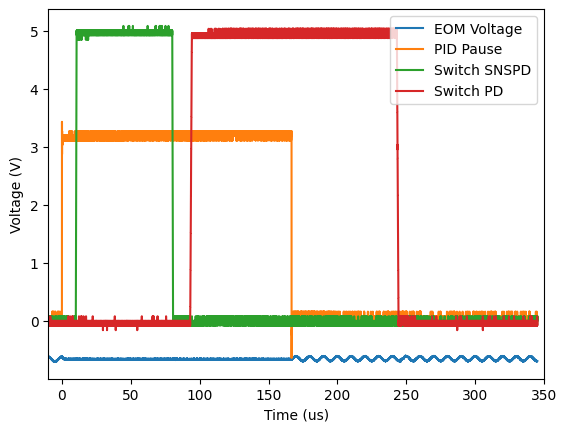

In [19]:
data = np.loadtxt("C:/Users/berni/Downloads/20250626-0002.csv", delimiter=",", skiprows=2)

time = data[:, 0]
eom_voltage = data[:, 1] * 1e-3 - 0.5
pid_pause = data[:, 2]
switch_snspd = data[:, 3]
switch_pd = data[:, 4]

plt.figure()
plt.plot(time, eom_voltage, label="EOM Voltage")
plt.plot(time, pid_pause, label="PID Pause")
plt.plot(time, switch_snspd, label="Switch SNSPD")
plt.plot(time, switch_pd, label="Switch PD")
plt.xlabel("Time (us)")
plt.ylabel("Voltage (V)")
plt.xlim(-10, 350)
plt.legend(loc="upper right")

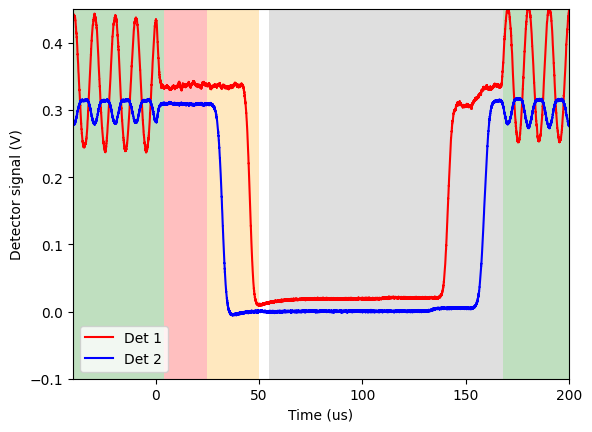

In [29]:
obj.rp.scope.single()
time.sleep(0.05)
curve1, curve2 = obj.rp.scope.save_curve()
times, ch1 = curve1.data
times, ch2 = curve2.data

plt.figure()
plt.fill_between([-50, 4], -1, 1, color='green', alpha=0.25, edgecolor='none')
plt.fill_between([4, 25], -1, 1, color='red', alpha=0.25, edgecolor='none')
plt.fill_between([25, 50], -1, 1, color='orange', alpha=0.25, edgecolor='none')
plt.fill_between([55, 168], -1, 1, color='gray', alpha=0.25, edgecolor='none')
plt.fill_between([168, 250], -1, 1, color='green', alpha=0.25, edgecolor='none')
plt.plot(times*1e6, ch1, label='Det 1', c="r")
plt.plot(times*1e6, ch2, label='Det 2', c="b")
plt.xlabel('Time (us)')
plt.ylabel('Detector signal (V)')
plt.legend()
plt.xlim(-40, 200)
plt.ylim(-0.1, 0.45)
plt.show()

In [21]:
obj.det_model_ch1.phase_relation(phi_setpoint), obj.det_model_ch2.phase_relation(phi_setpoint)

(0.34160506216766084, 0.27042585342694214)

In [35]:
from tqdm import tqdm
import random
num_shots = 100

avg_ch1_voltages = np.zeros(num_shots)
avg_ch2_voltages = np.zeros(num_shots)
random_ch1_voltages = np.zeros(num_shots)
random_ch2_voltages = np.zeros(num_shots)

for shot in tqdm(range(num_shots)):
    obj.rp.scope.single()
    time.sleep(0.05)
    curve1, curve2 = obj.rp.scope.save_curve()
    times, ch1 = curve1.data
    times, ch2 = curve2.data
    voltages_ch1_phase = ch1[np.logical_and(times > 4e-6, times < 25e-6)]
    voltages_ch2_phase = ch2[np.logical_and(times > 4e-6, times < 25e-6)]
    
    avg_ch1_voltages[shot] = np.mean(voltages_ch1_phase)
    avg_ch2_voltages[shot] = np.mean(voltages_ch2_phase)
    random_ch1_voltages[shot] = random.choice(voltages_ch1_phase)
    random_ch2_voltages[shot] = random.choice(voltages_ch2_phase)

100%|██████████| 100/100 [00:25<00:00,  3.92it/s]


In [34]:
obj.det_model_ch1.phase_relation(obj.phase_setpoint) - obj.det_model_ch2.phase_relation(obj.phase_setpoint)

-0.047781236187406206

In [2]:
plt.figure()
plt.hist(avg_ch1_voltages, bins=50, alpha=0.5, label='Avg Det 1', color='r')
plt.axvline(obj.det_model_ch1.phase_relation(obj.phase_setpoint), color='r', linestyle='--', label='Setpoint Det 1')
plt.hist(random_ch1_voltages, bins=50, alpha=0.5, label='Random Det 1', color='darkred')

NameError: name 'avg_ch1_voltages' is not defined

<Figure size 640x480 with 0 Axes>

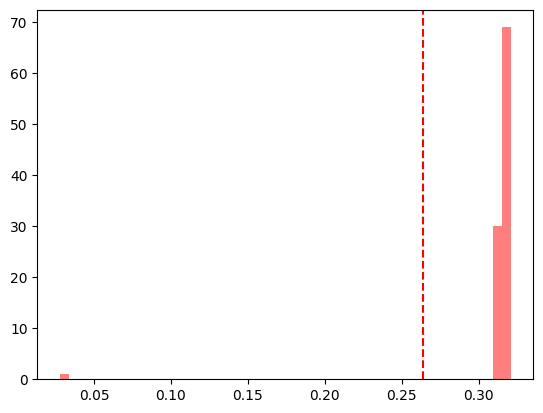

In [37]:
plt.figure()
plt.hist(avg_ch2_voltages, bins=50, alpha=0.5, label='Avg Det 1', color='r')
plt.axvline(obj.det_model_ch2.phase_relation(obj.phase_setpoint), color='r', linestyle='--', label='Setpoint Det 2')

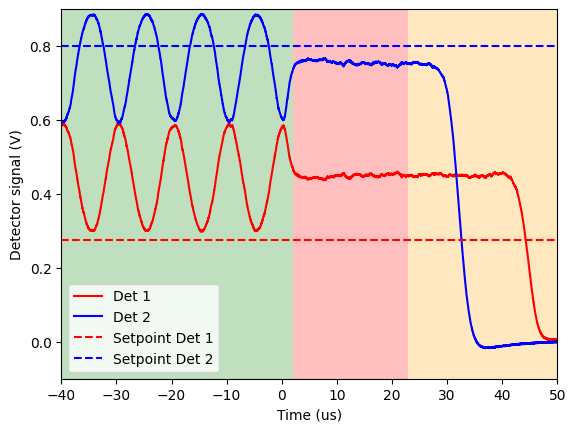

In [15]:
phi_setpoint = np.pi / 4

curve1, curve2 = obj.rp.scope.save_curve()
times, ch1 = curve1.data
times, ch2 = curve2.data
plt.figure()
plt.fill_between([-50, 2], -1, 1, color='green', alpha=0.25, edgecolor='none')
plt.fill_between([2, 23], -1, 1, color='red', alpha=0.25, edgecolor='none')
plt.fill_between([23, 50], -1, 1, color='orange', alpha=0.25, edgecolor='none')
plt.fill_between([55, 168], -1, 1, color='gray', alpha=0.25, edgecolor='none')
plt.fill_between([168, 250], -1, 1, color='green', alpha=0.25, edgecolor='none')
plt.plot(times*1e6, ch1, label='Det 1', c="r")
plt.plot(times*1e6, ch2, label='Det 2', c="b")
plt.axhline(obj.det_model_ch1.phase_relation(phi_setpoint), color='r', linestyle='--', label='Setpoint Det 1')
plt.axhline(obj.det_model_ch2.phase_relation(phi_setpoint), color='b', linestyle='--', label='Setpoint Det 2')
ylims = max(obj.det_model_ch1.phase_relation(phi_setpoint), obj.det_model_ch2.phase_relation(phi_setpoint))
plt.xlabel('Time (us)')
plt.ylabel('Detector signal (V)')
plt.legend()
plt.xlim(-40, 50)
plt.ylim(-0.1, ylims+0.1)
plt.show()

In [ ]:
obj.det_model_ch1.phase_relation(phi_setpoint) - obj.det_model_ch2.phase_relation(phi_setpoint)

-0.5249460269525996

: 

In [18]:
obj.det_model_ch1.phase_relation(np.pi-phi_setpoint), obj.det_model_ch2.phase_relation(np.pi-phi_setpoint)

(0.7902458632315319, 0.20925332275880604)

In [6]:
obj.setup_locking(np.pi/4)

100%|██████████| 500/500 [01:40<00:00,  4.98it/s]


Measured voltage ch1: 0.068 +/- 0.008 V, while expecting 0.059 V --> new setpoint: 0.165.
Measured voltage ch2: 0.262 +/- 0.007 V, while expecting 0.264 V --> new setpoint: 0.033.
Taking the average of the two, the new setpoint is: 0.099.


100%|██████████| 500/500 [01:41<00:00,  4.93it/s]


Measured voltage ch1: 0.068 +/- 0.008 V -> 0.059 +/- 0.007 V (expected 0.059 V) 
Measured voltage ch1: 0.262 +/- 0.007 V -> 0.273 +/- 0.006 V (expected 0.264 V)


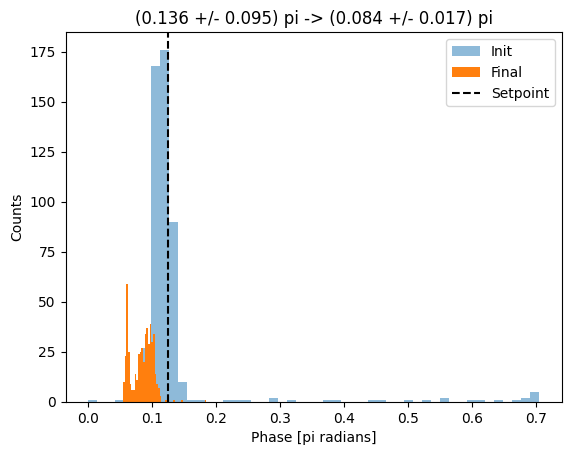

100%|██████████| 500/500 [01:43<00:00,  4.83it/s]


Measured voltage ch1: 0.083 +/- 0.013 V, while expecting 0.083 V --> new setpoint: -0.003.
Measured voltage ch2: 0.249 +/- 0.014 V, while expecting 0.231 V --> new setpoint: -0.193.
Taking the average of the two, the new setpoint is: -0.098.


100%|██████████| 500/500 [01:40<00:00,  4.98it/s]


Measured voltage ch1: 0.083 +/- 0.013 V -> 0.092 +/- 0.013 V (expected 0.083 V) 
Measured voltage ch1: 0.249 +/- 0.014 V -> 0.237 +/- 0.016 V (expected 0.231 V)


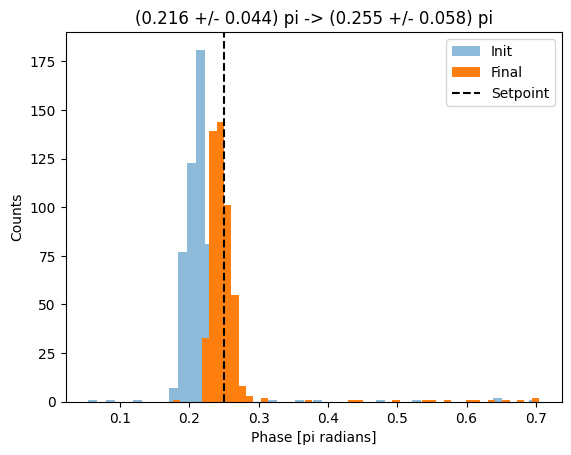

100%|██████████| 500/500 [01:43<00:00,  4.81it/s]


Measured voltage ch1: 0.115 +/- 0.016 V, while expecting 0.119 V --> new setpoint: -0.041.
Measured voltage ch2: 0.210 +/- 0.020 V, while expecting 0.181 V --> new setpoint: -0.210.
Taking the average of the two, the new setpoint is: -0.126.


100%|██████████| 500/500 [01:46<00:00,  4.69it/s]

Measured voltage ch1: 0.115 +/- 0.016 V -> 0.131 +/- 0.016 V (expected 0.119 V) 
Measured voltage ch1: 0.210 +/- 0.020 V -> 0.185 +/- 0.020 V (expected 0.181 V)


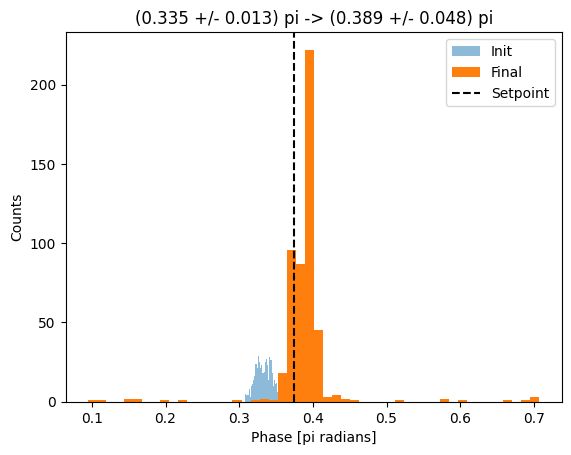

100%|██████████| 500/500 [01:44<00:00,  4.80it/s]


Measured voltage ch1: 0.159 +/- 0.016 V, while expecting 0.161 V --> new setpoint: -0.026.
Measured voltage ch2: 0.151 +/- 0.022 V, while expecting 0.123 V --> new setpoint: -0.184.
Taking the average of the two, the new setpoint is: -0.105.


100%|██████████| 500/500 [01:43<00:00,  4.81it/s]


Measured voltage ch1: 0.159 +/- 0.016 V -> 0.172 +/- 0.016 V (expected 0.161 V) 
Measured voltage ch1: 0.151 +/- 0.022 V -> 0.134 +/- 0.021 V (expected 0.123 V)


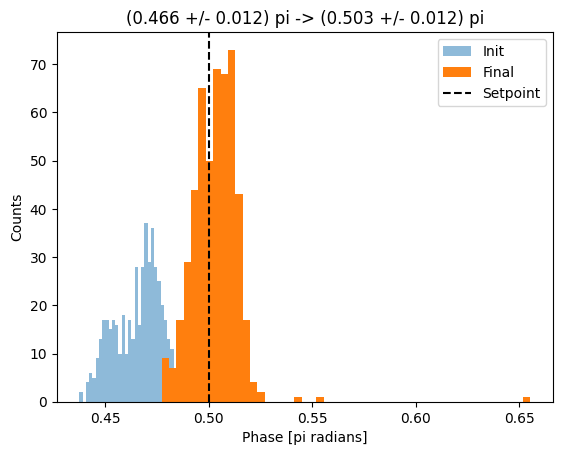

100%|██████████| 500/500 [01:52<00:00,  4.44it/s]


Measured voltage ch1: 0.195 +/- 0.013 V, while expecting 0.204 V --> new setpoint: -0.084.
Measured voltage ch2: 0.099 +/- 0.019 V, while expecting 0.064 V --> new setpoint: -0.234.
Taking the average of the two, the new setpoint is: -0.159.


100%|██████████| 500/500 [01:51<00:00,  4.48it/s]


Measured voltage ch1: 0.195 +/- 0.013 V -> 0.208 +/- 0.011 V (expected 0.204 V) 
Measured voltage ch1: 0.099 +/- 0.019 V -> 0.080 +/- 0.017 V (expected 0.064 V)


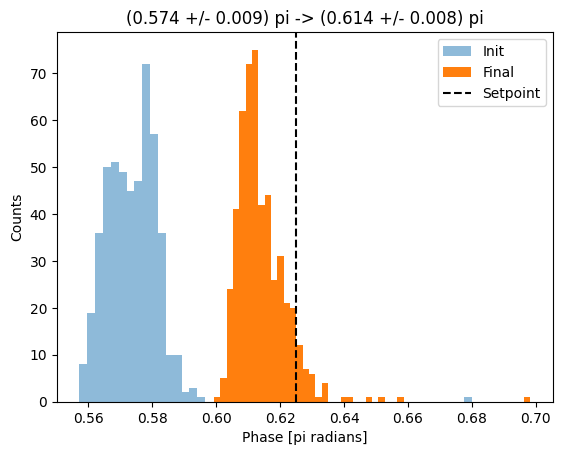

100%|██████████| 500/500 [01:44<00:00,  4.78it/s]


Measured voltage ch1: 0.215 +/- 0.008 V, while expecting 0.240 V --> new setpoint: -0.279.
Measured voltage ch2: 0.067 +/- 0.013 V, while expecting 0.015 V --> new setpoint: -0.401.
Taking the average of the two, the new setpoint is: -0.340.


100%|██████████| 500/500 [01:46<00:00,  4.69it/s]


Measured voltage ch1: 0.215 +/- 0.008 V -> 0.229 +/- 0.003 V (expected 0.240 V) 
Measured voltage ch1: 0.067 +/- 0.013 V -> 0.040 +/- 0.006 V (expected 0.015 V)


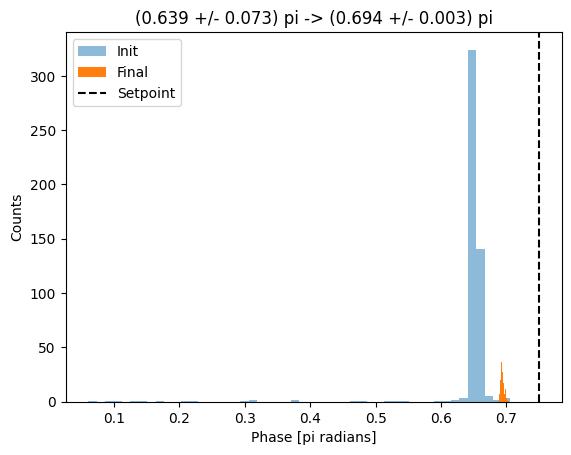

In [22]:
phases_to_test = [np.pi/8, np.pi / 4, 3*np.pi/8, np.pi / 2, 5*np.pi/8, 3 * np.pi / 4]
num_points = 500
final_phases_measured = np.zeros((len(phases_to_test), num_points))

for idx, phi in enumerate(phases_to_test):
    obj.setup_locking(phi)
    obj.rp.iq0.setup(output_direct="out1")
    obj.rp.asg0.setup(output_direct="off")
    obj.rp.pid0.setup(output_direct="out1")
    obj.rp.pid0.reg_integral = 0.0
    time.sleep(0.5)
    obj.improve_lock_accuracy(num_points, max_tolerance=0.05, do_print=True, do_analyze=True)
    final_phases_measured[idx,:] = obj.phases_final
    obj.rp.pid0.setup(outpu_direct="off", setpoint=0.0)

100%|██████████| 500/500 [01:40<00:00,  4.99it/s]


Measured voltage ch1: 0.226 +/- 0.003 V, while expecting 0.243 V --> new setpoint: -0.354.
Measured voltage ch2: 0.039 +/- 0.007 V, while expecting -0.015 V --> new setpoint: -0.581.
Taking the average of the two, the new setpoint is: -0.467.


100%|██████████| 500/500 [01:40<00:00,  4.97it/s]


Measured voltage ch1: 0.226 +/- 0.003 V -> 0.218 +/- 0.008 V (expected 0.243 V) 
Measured voltage ch1: 0.039 +/- 0.007 V -> 0.038 +/- 0.007 V (expected -0.015 V)


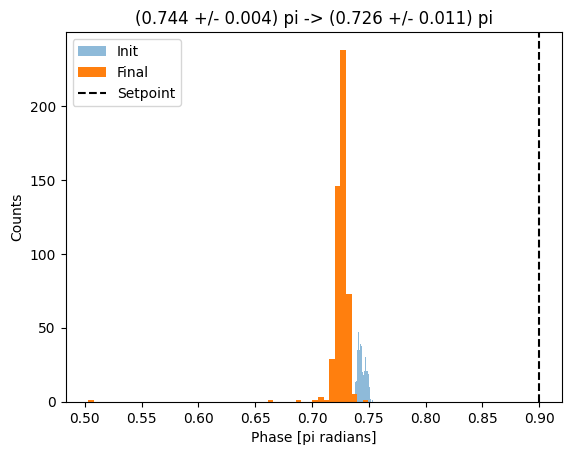

In [17]:
obj.setup_locking(0.9*np.pi)
obj.improve_lock_accuracy(num_points, max_tolerance=0.05, do_print=True, do_analyze=True)

In [42]:
obj.setup_locking(0)

In [10]:
final_phases_measured.shape

(5, 500)

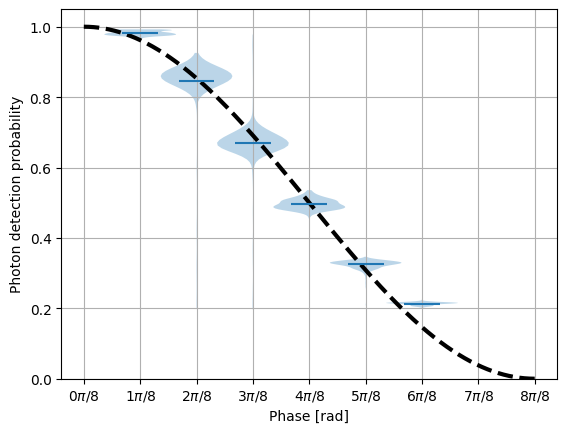

In [38]:
phases_plot = np.linspace(0, np.pi, 1000)

plt.grid()
plt.plot(phases_plot, 1/2 + 1/2*np.cos(phases_plot), color='black', linestyle='--', lw=3)
plt.violinplot(1/2 + 1/2*np.cos(final_phases_measured.T), positions = phases_to_test, showextrema=False, showmeans=True)
plt.ylim(0, 1.05)
plt.xticks([0]+phases_to_test+[7*np.pi/8, np.pi], [r"$%.i \pi/ 8$"%p for p in range(len(phases_to_test)+3)])
plt.xlabel("Phase [rad]")
plt.ylabel("Photon detection probability")
plt.show()

In [49]:
obj.det_model_ch1.phase_relation(np.pi) - obj.det_model_ch2.phase_relation(np.pi)

0.3019714142533041

In [48]:
obj.setup_locking(np.pi/2)

100%|██████████| 500/500 [01:27<00:00,  5.73it/s]


Measured voltage ch1: 0.096 +/- 0.015 V, while expecting 0.069 V --> new setpoint: 0.380.
Measured voltage ch2: 0.231 +/- 0.019 V, while expecting 0.254 V --> new setpoint: 0.225.
Taking the average of the two, the new setpoint is: 0.302.


100%|██████████| 500/500 [01:27<00:00,  5.74it/s]


Measured voltage ch1: 0.096 +/- 0.015 V -> 0.076 +/- 0.012 V (expected 0.069 V) 
Measured voltage ch1: 0.231 +/- 0.019 V -> 0.256 +/- 0.015 V (expected 0.254 V)


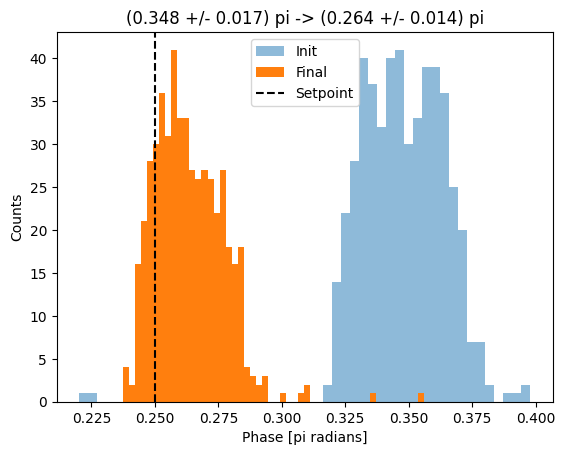

ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 1
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 2
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 3
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 4
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 5
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 6
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40120000 to _reads value 16384 by client 7
ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at ad

In [11]:
obj.improve_lock_accuracy(500, max_tolerance=0.05, do_print=True, do_analyze=True)

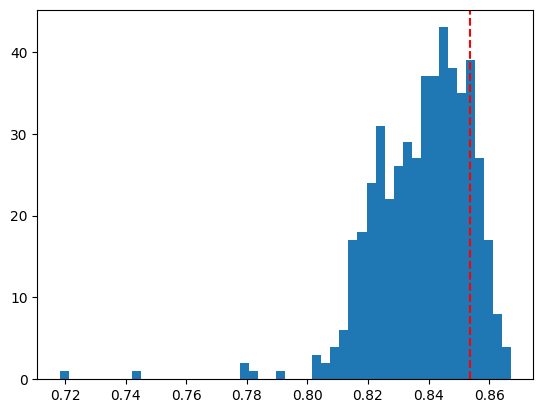

In [17]:
plt.hist(1/2 + 1/2 * np.cos(obj.phases_final), bins=50)
plt.axvline(1/2 + 1/2 * np.cos(phi_setpoint), color='red', linestyle='--')

{'bodies': [<matplotlib.collections.PolyCollection at 0x2140a6ef040>]}

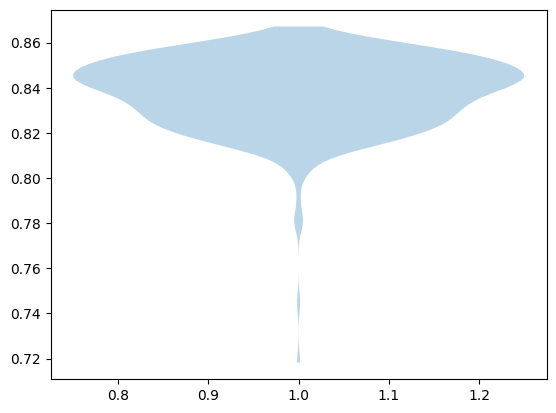

In [19]:
plt.violinplot(1/2 + 1/2 * np.cos(obj.phases_final), showextrema=False)

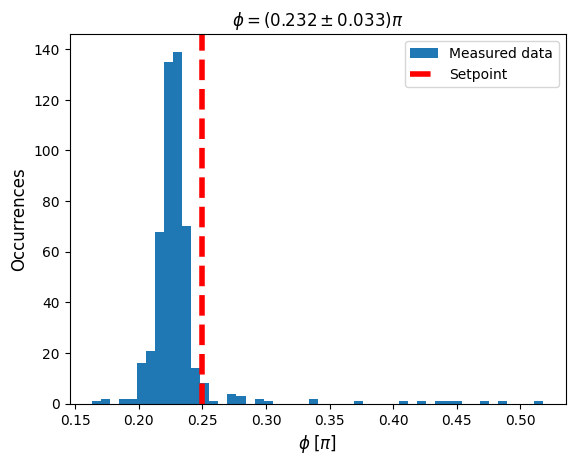

In [8]:
plt.figure()
plt.hist(obj.phases_final/np.pi, bins=50, label="Measured data")
plt.xlabel(r"$\phi \; [\pi]$", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
plt.title(r"$\phi = (%.3f \pm %.3f)\pi$" % (np.mean(obj.phases_final)/np.pi, np.std(obj.phases_final)/np.pi))
plt.axvline(phi_setpoint/np.pi, color='red', linestyle='--', label='Setpoint', lw=4)
# plt.xlim(0.7, 0.8)
plt.legend()
plt.show()

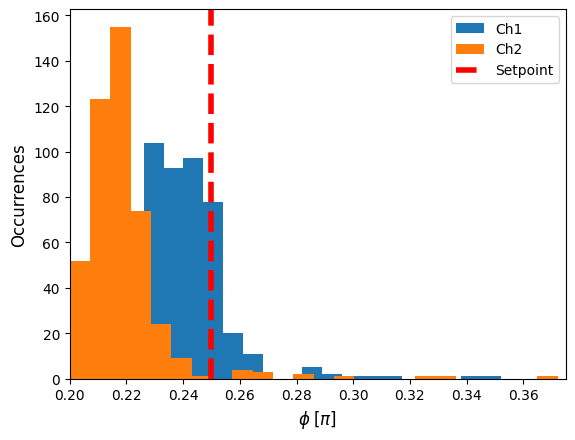

In [10]:
plt.figure()
plt.hist(obj.phases_ch1_final/np.pi, bins=50, label="Ch1")
plt.hist(obj.phases_ch2_final/np.pi, bins=50, label="Ch2")
plt.xlabel(r"$\phi \; [\pi]$", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
# plt.title(r"$\phi = (%.3f \pm %.3f)\pi$" % (np.mean(obj.phases_final)/np.pi, np.std(obj.phases_final)/np.pi))
plt.axvline(phi_setpoint/np.pi, color='red', linestyle='--', label='Setpoint', lw=4)
plt.xlim(0.2, 0.375)
plt.legend()
plt.show()

In [33]:
obj.unlock()